In [43]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_ollama import ChatOllama
from typing import Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from langchain.messages import RemoveMessage, SystemMessage
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig

In [44]:
class State(MessagesState):
    context: Annotated[str, "The context from the RAG tool to provide relevant information."]
    approval: Annotated[str, "Whether the user approves to book the ticket or not."]
    feedback: Annotated[str, "User feedback on the booking process."]
    should_book: Annotated[bool, "A boolean indicating whether the user wants to book the ticket or not."]

llm = ChatOllama(model="llama3.1")

In [45]:
@tool
def rag_tool(query: str) -> str:
    """
    RAG tool that retrieves relevant information based on the user's query related to weather of the destination.
    """
    # Implement the RAG logic here
    return "The weather of the location is fabulous. The best time to visit is during the spring season."
llm_with_tools = llm.bind_tools([rag_tool])

In [46]:
def chat_node(state: State, config: RunnableConfig, store: BaseStore) -> State:
    user_id = config["configurable"]["user_id"]
    namespace = ("users", user_id) # The namespace is just the grouping
    
    # Get the item using namespace AND key
    item = store.get(namespace, "summary_key") 
    
    # Extract the text from the item's value dict (if it exists)
    summary_text = item.value["text"] if item else ""
    context = state.get("context", "")
    
    sys_prompt = f"You are a travel assistant. Context: {context} \nSummary of past turns: {summary_text}"
    messages_to_pass = [SystemMessage(content=sys_prompt)] + state["messages"]
    
    response = llm_with_tools.invoke(messages_to_pass)
    return {"messages": [response]}

def book_trip_node(state: State) -> State:
    decision = interrupt({
        'type' : 'approval',
        'message' : 'Do you approve to book the trip? (yes/no)'
    })
    return {
        'approval' : decision.get('approval', 'no'),
        'feedback' : decision.get('feedback', 'No feedback provided.')
    }

def summary_node(state: State, config: RunnableConfig, store: BaseStore) -> State:
    user_id = config["configurable"]["user_id"]
    namespace = ("users", user_id)
    
    item = store.get(namespace, "summary_key")
    summary_text = item.value["text"] if item else ""
    
    if summary_text:
        prompt = f"Existing summary: {summary_text}\n\nExtend the summary based on the latest messages..."
    else:
        prompt = f"Create a summary based on the latest messages..."
        
    prompt_for_summary = prompt + "\n\n LATEST MESSAGES: " + " ".join([msg.content for msg in state["messages"]])
    
    # FIX: Use .invoke() instead of calling llm directly
    new_summary = llm.invoke(prompt_for_summary) 
    
    # FIX: Save it as a dictionary under the key "summary_key"
    store.put(namespace, "summary_key", {"text": new_summary.content})
    
    messages_to_remove = []
    if len(state["messages"]) > 5:
        messages_to_remove = state["messages"][:5]
        
    return {
        "messages" : [RemoveMessage(m.id) for m in messages_to_remove]
    }

def custom_router(state: State):
    last_message = state["messages"][-1]
    
    # 1. Check for tool calls first (replaces standard tools_condition)
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"
        
    # 2. If no tools were called, decide whether to book or summarize
    prompt = f"""
        You are a travel assistant routing the conversation. 
        Determine if the user wants to book the trip now. Return 'book_trip' or 'chat'.
        LATEST MESSAGE: {last_message.content}
    """
    response = llm.invoke(prompt)
    if "book_trip" in response.content.lower():
        return "book_trip"
    else:
        return "summary"

In [47]:
builder = StateGraph(State)
# conn = sqlite3.connect("travel_graph.db")
# store = SqliteSaver(conn)
store = InMemoryStore()
saver = InMemorySaver()
tool_node = ToolNode([rag_tool])

builder.add_node("chat", chat_node)
builder.add_node("tools", tool_node)
builder.add_node("book_trip", book_trip_node)
builder.add_node("summary", summary_node)

builder.add_edge(START, "chat")
builder.add_edge("tools", "chat") # Loop back to chat after tool executes

# Combine routing logic here using the custom_router
builder.add_conditional_edges("chat", custom_router, {
    "tools": "tools",
    "book_trip": "book_trip",
    "summary": "summary"
})

builder.add_edge("book_trip", END)
builder.add_edge("summary", END)

# We will add memory here next!
graph = builder.compile(store=store, checkpointer=saver)

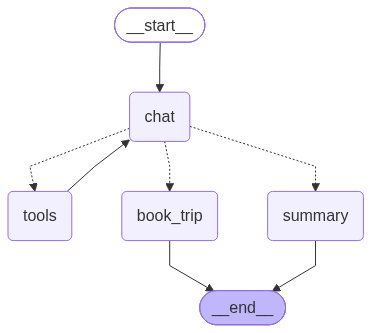

In [48]:
graph

In [49]:
if __name__ == "__main__":
    config = {"configurable" : {"thread_id": "12345", "user_id": "user_1"}}
    print("✈️ VIP Travel Assistant Started (type 'q' to quit)")
    print("-" * 50)
    while True:
        snapshot = graph.get_state(config=config)
        if snapshot.tasks and snapshot.tasks[0].interrupts:
            interrupt_data = snapshot.tasks[0].interrupts[0].value
            print(f"\n⚠️ SYSTEM PROMPT: {interrupt_data['message']}")
            decision = input("Your response: ")
            print("Processing...")
            graph.invoke(Command(resume={"approval" : decision.lower(), "feedback" : "User provided feedback."}), config=config)
            print("✅ Booking processed! What else can I help you with?\n")
            continue
        user_input = input("You: ")
        if user_input.lower() == 'q':
            print("Exiting the travel assistant. Goodbye!")
            break
        result = graph.invoke({"messages" : [("user", user_input)]}, config=config)
        final_message = result["messages"][-1].content 
        print(f"Travel Assistant: {final_message}")

✈️ VIP Travel Assistant Started (type 'q' to quit)
--------------------------------------------------
Travel Assistant: Based on your interest in traveling to Paris, I'd be happy to provide you with more information.

Paris, the City of Light, is a must-visit destination for any traveler. Here are some top recommendations:

1. **Must-see attractions:**
	* The Eiffel Tower (iron lattice tower and iconic symbol of Paris)
	* The Louvre Museum (world-renowned art museum with an impressive collection)
	* Notre-Dame Cathedral (historic and beautiful Gothic church)
2. **Cultural experiences:**
	* Visit the Musée d'Orsay for an extensive collection of Impressionist and Post-Impressionist art
	* Explore the charming Montmartre neighborhood, famous for its bohemian vibe and stunning views
	* Enjoy a Seine River cruise to see the city's landmarks from a different perspective
3. **Food and drink:**
	* Indulge in French cuisine at a classic bistro or try modern twists at trendy restaurants
	* Sampl